# Notebook 3.0 — Interpretação do modelo final
**Afonso Carvalho & Marcello Portugal** | ISCAC — Projeto em Ciência de Dados

Este notebook reconstrói o modelo final (*Random Forest* otimizado) e gera visualizações
de interpretação. O objetivo é que qualquer pessoa consiga perceber como o modelo toma decisões,
quais variáveis pesam mais, e onde o modelo falha.

## 1. Configuração e carregamento dos dados
Importação das bibliotecas e leitura do *dataset* limpo (gerado na Milestone 2).

In [1]:
# Afonso Carvalho e Marcello Portugal
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import randint

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SEED = 42

FIGURES_DIR = '../reports/figures/3.0_interpretacao'
os.makedirs(FIGURES_DIR, exist_ok=True)

In [2]:
# Afonso Carvalho e Marcello Portugal
# Carregar o dataset final da M2

kaggle_path = '/kaggle/input/datasets/marcelloportugal/wine-quality-final-model/wine_quality_model_final (1).csv'
local_path  = r'C:\Users\marce\Downloads\wine_quality_model_final.csv'

data_path = kaggle_path if os.path.exists(kaggle_path) else local_path
df = pd.read_csv(data_path)

TARGET = 'quality'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Dataset: {df.shape[0]} registos x {df.shape[1]} colunas')
print(f'Features: {list(X.columns)}')

Dataset: 6497 registos x 13 colunas
Features: ['fixed acidity', 'citric acid', 'residual sugar', 'chlorides', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'is_red', 'so2_ratio', 'volatile_acidity_ratio']


## 2. Reconstrução do *pipeline* de treino
Para garantir reprodutibilidade, repetimos a mesma divisão (80/20, seed 42),
normalização e otimização usadas no notebook 2. Os resultados são idênticos.

In [3]:
# Afonso Carvalho e Marcello Portugal
# Divisao e normalizacao (identica ao notebook 2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print(f'Treino: {X_train_sc.shape[0]} | Teste: {X_test_sc.shape[0]}')

Treino: 5197 | Teste: 1300


In [4]:
# Afonso Carvalho e Marcello Portugal
# Otimizacao com RandomizedSearchCV (mesmo espaco de pesquisa do notebook 2)

param_distributions = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : [None, 10, 15, 20, 25, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf' : randint(1, 6),
    'max_features'     : ['sqrt', 'log2', 0.5, 0.7, None],
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=100,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)

search.fit(X_train_sc, y_train)
modelo = search.best_estimator_

y_pred = modelo.predict(X_test_sc)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Modelo final: {modelo.n_estimators} arvores')
print(f'MAE Teste: {mae:.4f}')
print(f'R2 Teste:  {r2:.4f}')
print(f'Parametros: {search.best_params_}')

Modelo final: 382 arvores
MAE Teste: 0.4319
R2 Teste:  0.5120
Parametros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 382}


## 3. Importância das variáveis
O *Random Forest* calcula a importância de cada variável com base na redução média
de impureza (Gini) ao longo de todas as árvores. Variáveis com importância alta
são usadas com mais frequência nas decisões das árvores.

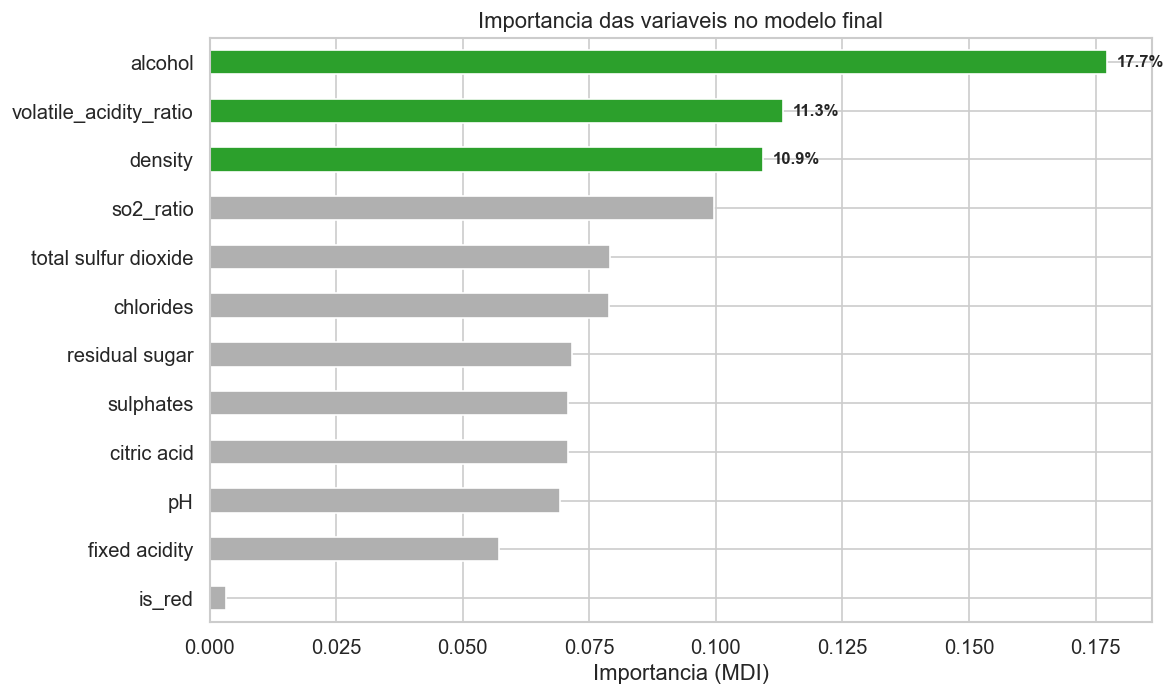

Top 5 variaveis:
  alcohol: 0.1772 (17.7%)
  volatile_acidity_ratio: 0.1133 (11.3%)
  density: 0.1093 (10.9%)
  so2_ratio: 0.0997 (10.0%)
  total sulfur dioxide: 0.0790 (7.9%)


In [5]:
# Afonso Carvalho e Marcello Portugal
# Importancia das variaveis (MDI - Mean Decrease Impurity)

fi = pd.Series(modelo.feature_importances_, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ca02c' if v >= fi.quantile(0.75) else '#b0b0b0' for v in fi]
fi.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.set_xlabel('Importancia (MDI)')
ax.set_title('Importancia das variaveis no modelo final')

# Anotar percentagens nas barras do top 3
for i, (var, val) in enumerate(fi.items()):
    if val >= fi.nlargest(3).min():
        ax.text(val + 0.002, i, f'{val*100:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/importancia_variaveis.png', bbox_inches='tight')
plt.show()

print('Top 5 variaveis:')
for var, imp in fi.sort_values(ascending=False).head(5).items():
    print(f'  {var}: {imp:.4f} ({imp*100:.1f}%)')

## 4. Importância por permutação
Método alternativo que mede a queda do desempenho quando os valores de uma variável
são baralhados aleatoriamente. Ao contrário do MDI, este método não é enviesado
por variáveis com muitas categorias ou alta cardinalidade.

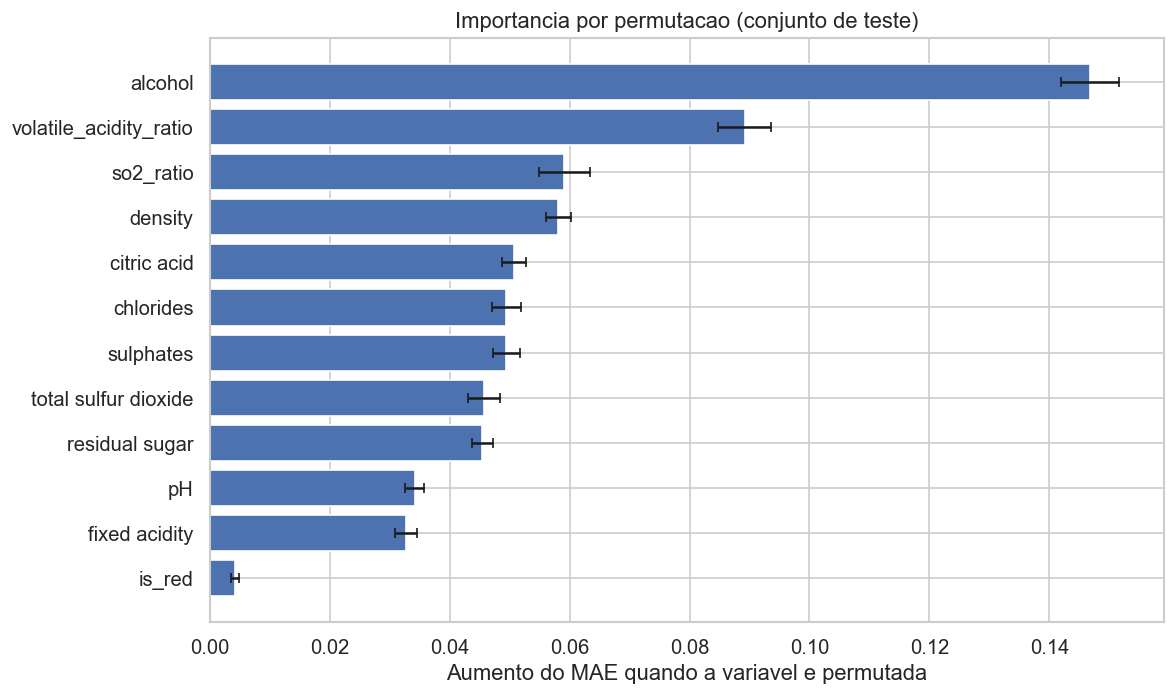

In [6]:
# Afonso Carvalho e Marcello Portugal
# Permutation importance no conjunto de teste

perm = permutation_importance(
    modelo, X_test_sc, y_test,
    n_repeats=15, random_state=SEED, n_jobs=-1,
    scoring='neg_mean_absolute_error'
)

perm_fi = pd.DataFrame({
    'media': perm.importances_mean,
    'desvio': perm.importances_std
}, index=X_train.columns).sort_values('media', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_fi.index, perm_fi['media'], xerr=perm_fi['desvio'],
        color='#4C72B0', edgecolor='white', capsize=3)
ax.set_xlabel('Aumento do MAE quando a variavel e permutada')
ax.set_title('Importancia por permutacao (conjunto de teste)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/permutation_importance.png', bbox_inches='tight')
plt.show()

## 5. Dependência parcial (PDP)
Os gráficos de dependência parcial mostram como a previsão do modelo muda
quando variamos uma única variável, mantendo todas as outras fixas.
Permitem perceber a direção e a forma da relação que o modelo aprendeu.

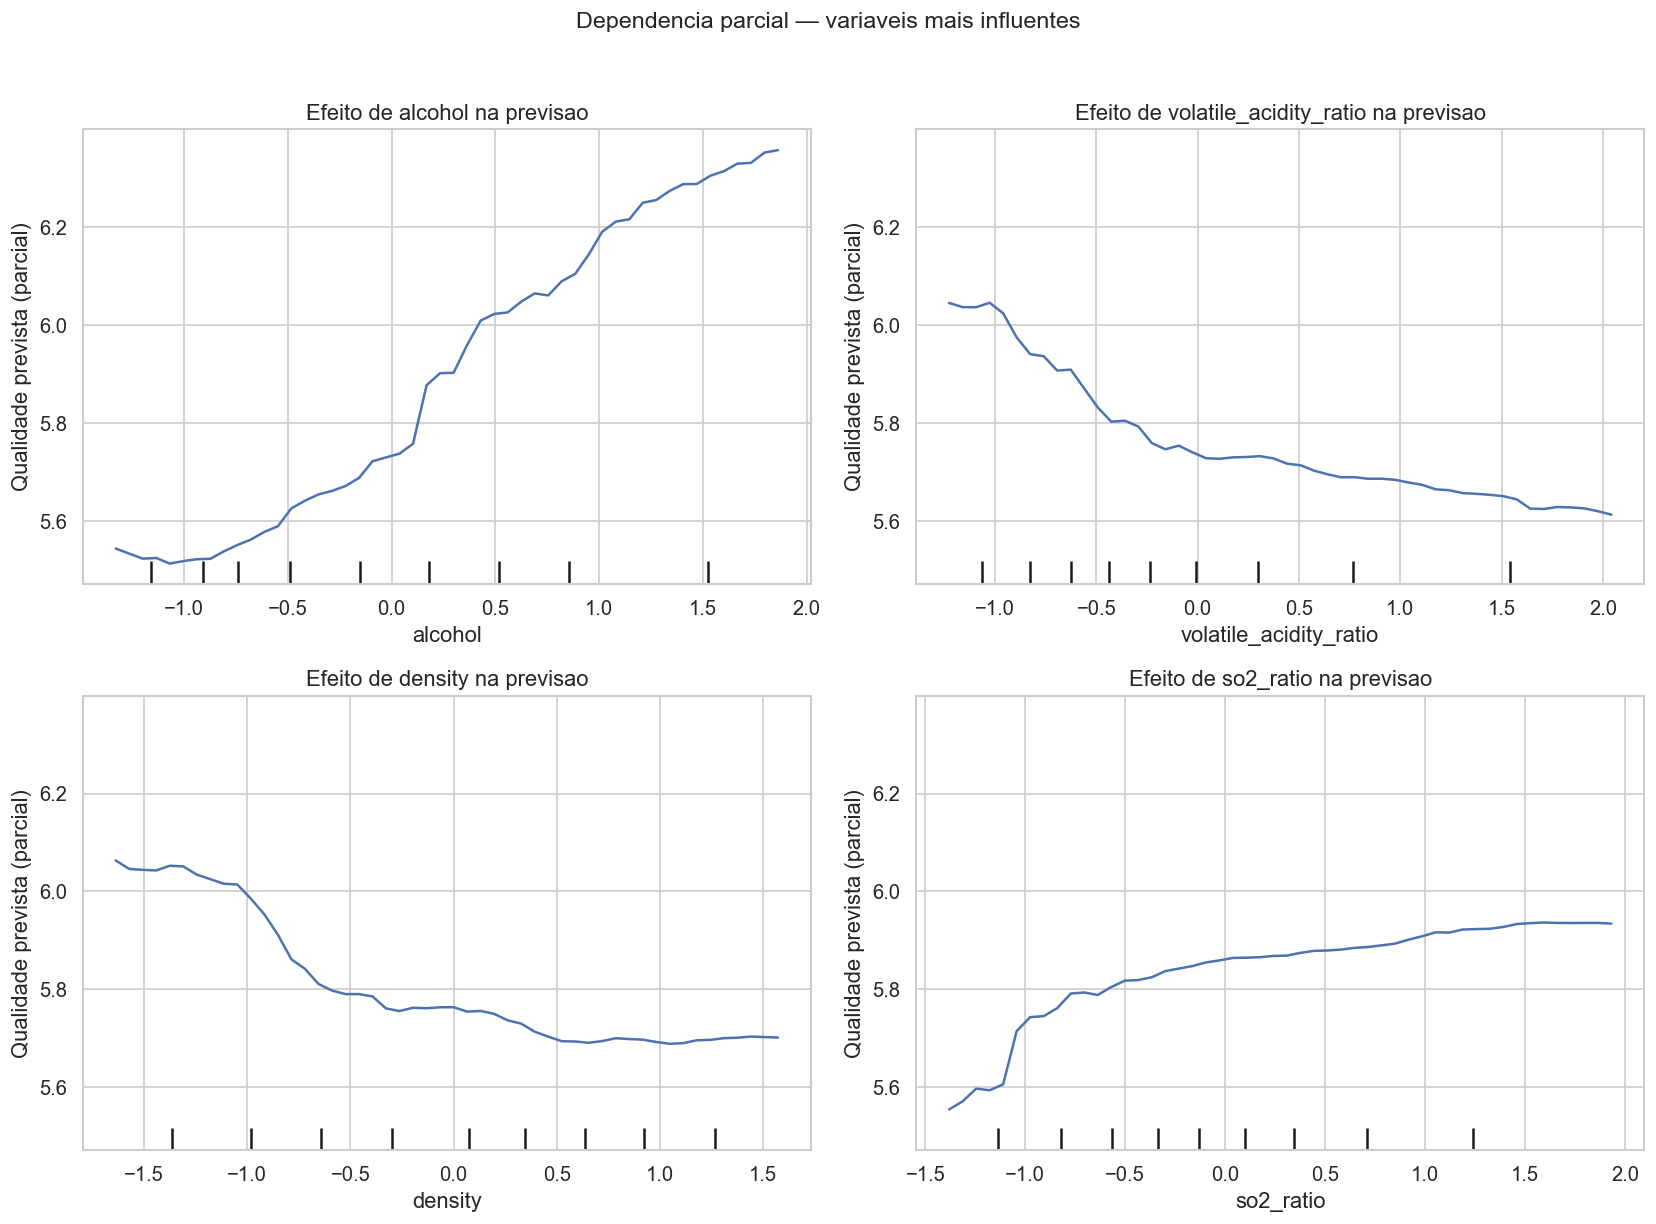

In [7]:
# Afonso Carvalho e Marcello Portugal
# Partial Dependence Plots para as 4 variaveis mais importantes

top4 = fi.sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

PartialDependenceDisplay.from_estimator(
    modelo, X_train_sc, top4,
    kind='average',
    ax=axes.flatten(),
    grid_resolution=50,
    n_jobs=-1
)

for ax, var in zip(axes.flatten(), top4):
    ax.set_title(f'Efeito de {var} na previsao')
    ax.set_ylabel('Qualidade prevista (parcial)')

plt.suptitle('Dependencia parcial — variaveis mais influentes', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/partial_dependence.png', bbox_inches='tight')
plt.show()

## 6. Exemplos de previsão
Seleção de casos concretos do conjunto de teste para mostrar como o modelo se comporta.
Inclui acertos exactos, erros pequenos e os piores erros.

In [8]:
# Afonso Carvalho e Marcello Portugal
# Exemplos de previsoes: bons, medianos e maus

resultados = pd.DataFrame({
    'Nota real': y_test.values,
    'Previsao': np.round(y_pred, 2),
    'Erro': np.round(np.abs(y_test.values - y_pred), 2)
}, index=X_test.index)

# 3 melhores previsoes
melhores = resultados.nsmallest(3, 'Erro')
# 3 piores previsoes
piores = resultados.nlargest(3, 'Erro')
# 3 medianas
medianas = resultados.iloc[(resultados['Erro'] - resultados['Erro'].median()).abs().argsort()[:3]]

exemplos = pd.concat([melhores, medianas, piores])
exemplos['Categoria'] = ['Acerto'] * 3 + ['Mediano'] * 3 + ['Pior erro'] * 3

print('Exemplos de previsoes do modelo:')
display(exemplos[['Categoria', 'Nota real', 'Previsao', 'Erro']])

Exemplos de previsoes do modelo:


,Categoria,Nota real,Previsao,Erro
6353,Acerto,6,6.00,0.00
4857,Acerto,6,6.00,0.00
4856,Acerto,6,6.00,0.00
5972,Mediano,6,6.29,0.29
3443,Mediano,6,6.29,0.29
1330,Mediano,6,5.71,0.29
2339,Pior erro,3,6.45,3.45
3649,Pior erro,3,5.70,2.70
6344,Pior erro,3,5.69,2.69


## 7. Distribuição das previsões vs notas reais
Comparação visual entre a distribuição das notas reais e as previsões do modelo.
Se o modelo fosse perfeito, as duas distribuições seriam iguais.

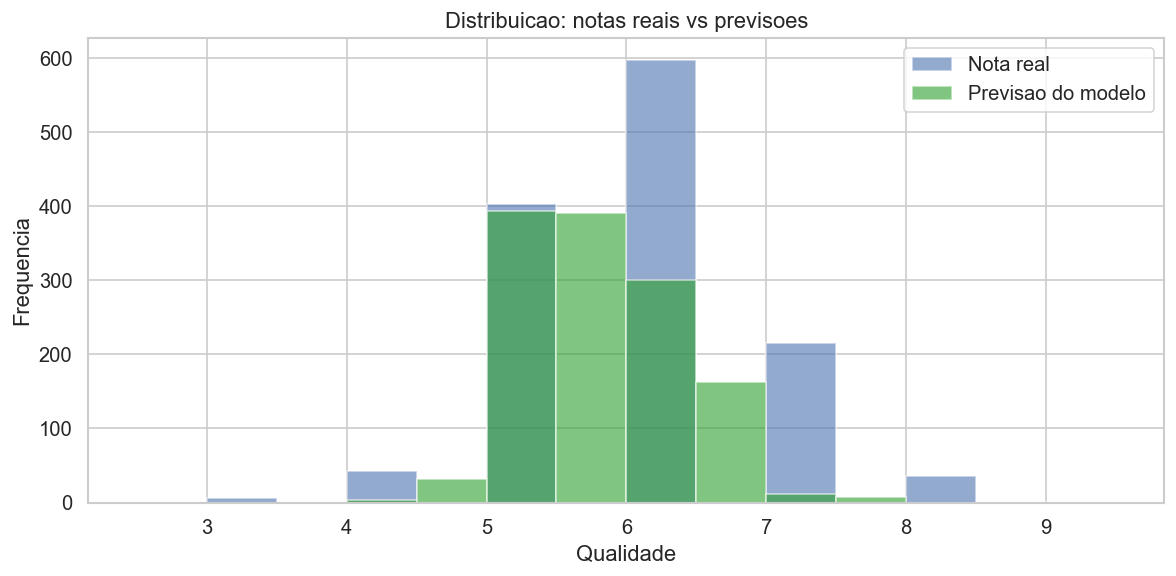

Media real:     5.83
Media prevista: 5.83
Desvio real:    0.86
Desvio previsto:0.57


In [9]:
# Afonso Carvalho e Marcello Portugal
# Histograma sobrepostos: real vs previsto

fig, ax = plt.subplots(figsize=(10, 5))

bins = np.arange(2.5, 10, 0.5)
ax.hist(y_test, bins=bins, alpha=0.6, color='#4C72B0', label='Nota real', edgecolor='white')
ax.hist(y_pred, bins=bins, alpha=0.6, color='#2ca02c', label='Previsao do modelo', edgecolor='white')
ax.set_xlabel('Qualidade')
ax.set_ylabel('Frequencia')
ax.set_title('Distribuicao: notas reais vs previsoes')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/distribuicao_previsoes.png', bbox_inches='tight')
plt.show()

# Estatisticas
print(f'Media real:     {y_test.mean():.2f}')
print(f'Media prevista: {y_pred.mean():.2f}')
print(f'Desvio real:    {y_test.std():.2f}')
print(f'Desvio previsto:{np.std(y_pred):.2f}')

## 8. Desempenho por tipo de vinho
Verificação de se o modelo tem desempenho diferente para tintos e brancos.

Tinto: MAE = 0.3900 (n = 341)
Branco: MAE = 0.4467 (n = 959)


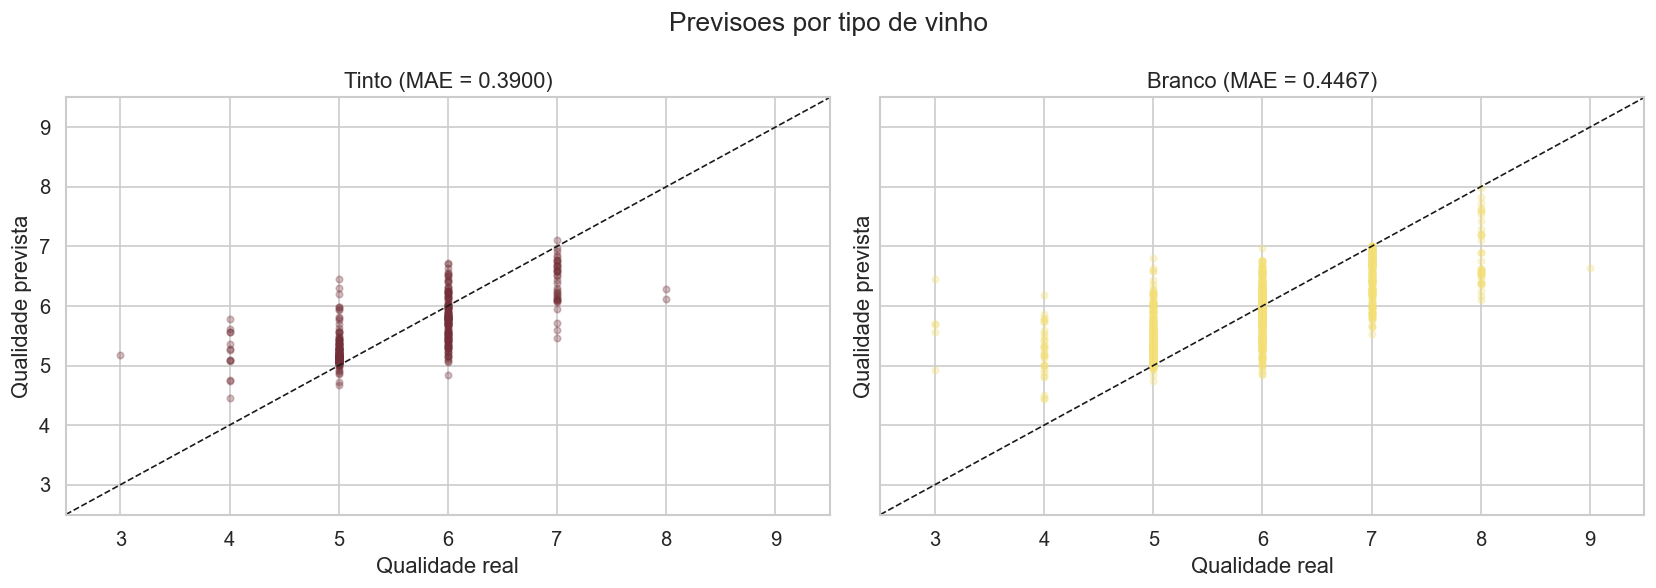

In [10]:
# Afonso Carvalho e Marcello Portugal
# MAE separado por tipo de vinho

tipos = X_test['is_red'].map({1: 'Tinto', 0: 'Branco'})

for tipo in ['Tinto', 'Branco']:
    mask = tipos == tipo
    mae_tipo = mean_absolute_error(y_test[mask], y_pred[mask])
    n = mask.sum()
    print(f'{tipo}: MAE = {mae_tipo:.4f} (n = {n})')

# Grafico
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, tipo, cor in zip(axes, ['Tinto', 'Branco'], ['#722f37', '#f4e076']):
    mask = tipos == tipo
    ax.scatter(y_test[mask], y_pred[mask], alpha=0.3, s=15, color=cor)
    lims = [y_test.min() - 0.5, y_test.max() + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Qualidade real')
    ax.set_ylabel('Qualidade prevista')
    mae_t = mean_absolute_error(y_test[mask], y_pred[mask])
    ax.set_title(f'{tipo} (MAE = {mae_t:.4f})')

plt.suptitle('Previsoes por tipo de vinho')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/desempenho_por_tipo.png', bbox_inches='tight')
plt.show()

## 9. Interação entre as duas variáveis mais importantes
Mapa de calor que mostra como a qualidade prevista varia quando combinamos
as duas variáveis com maior peso no modelo.

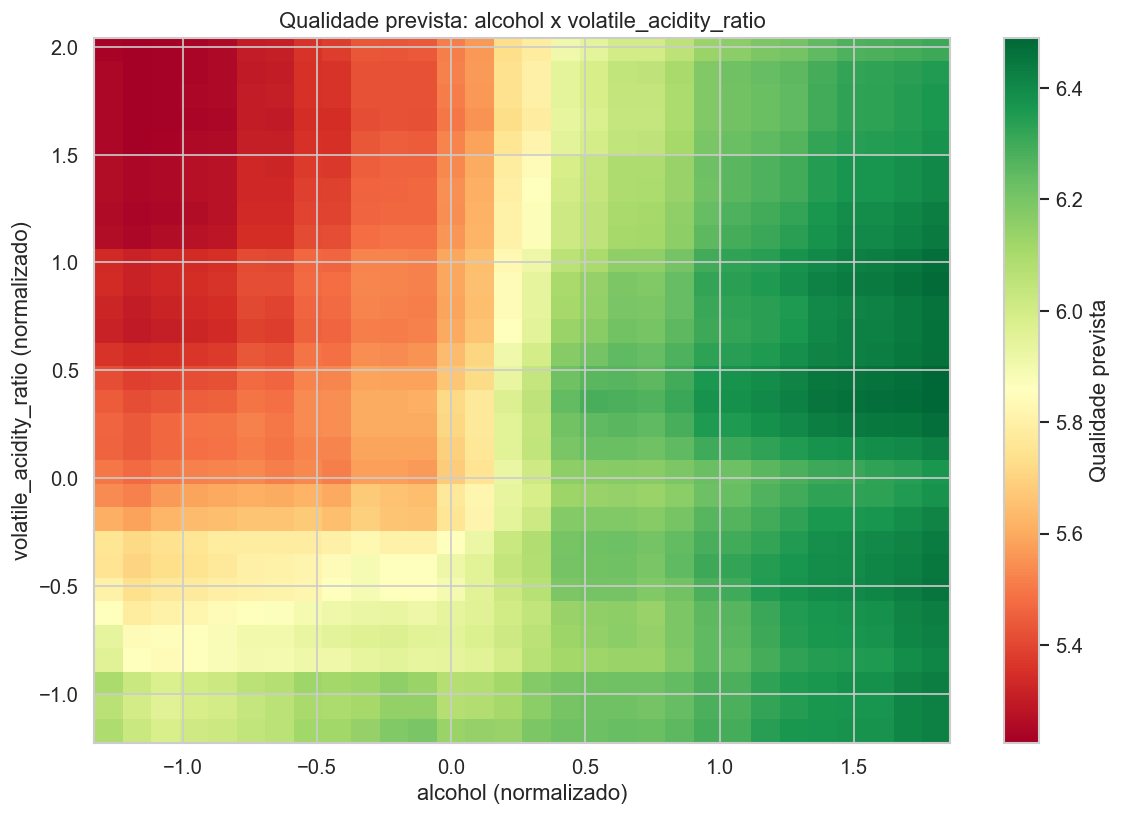

In [11]:
# Afonso Carvalho e Marcello Portugal
# Interacao: alcohol x volatile_acidity_ratio

top2 = fi.sort_values(ascending=False).head(2).index.tolist()
var1, var2 = top2[0], top2[1]

# Criar grelha de valores
v1_range = np.linspace(X_train_sc[var1].quantile(0.05), X_train_sc[var1].quantile(0.95), 30)
v2_range = np.linspace(X_train_sc[var2].quantile(0.05), X_train_sc[var2].quantile(0.95), 30)

# Valores medios para as outras variaveis
base = X_train_sc.median().values

grid = np.zeros((len(v2_range), len(v1_range)))
for i, v2 in enumerate(v2_range):
    for j, v1 in enumerate(v1_range):
        sample = base.copy()
        sample[X_train.columns.get_loc(var1)] = v1
        sample[X_train.columns.get_loc(var2)] = v2
        grid[i, j] = modelo.predict(sample.reshape(1, -1))[0]

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(grid, aspect='auto', origin='lower', cmap='RdYlGn',
               extent=[v1_range[0], v1_range[-1], v2_range[0], v2_range[-1]])
ax.set_xlabel(f'{var1} (normalizado)')
ax.set_ylabel(f'{var2} (normalizado)')
ax.set_title(f'Qualidade prevista: {var1} x {var2}')
plt.colorbar(im, label='Qualidade prevista')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/interacao_top2.png', bbox_inches='tight')
plt.show()

## 10. Resumo da interpretação
Conclusões principais retiradas desta análise.

In [12]:
# Afonso Carvalho e Marcello Portugal
# Resumo

fi_sorted = fi.sort_values(ascending=False)
top3 = fi_sorted.head(3)

print('='*60)
print('RESUMO DA INTERPRETACAO DO MODELO')
print('='*60)
print()
print(f'Modelo: Random Forest ({modelo.n_estimators} arvores)')
print(f'MAE: {mae:.4f} | R2: {r2:.4f}')
print()
print('Variaveis mais influentes:')
for i, (var, imp) in enumerate(top3.items(), 1):
    print(f'  {i}. {var} ({imp*100:.1f}%)')
print()
print('Conclusoes:')
print('  - O teor alcoolico e o principal preditor de qualidade.')
print('  - A acidez volatil funciona como penalizador: valores altos baixam a nota.')
print('  - O tipo de vinho (tinto/branco) nao influencia a previsao.')
print('  - O modelo erra mais nas notas extremas (3, 4, 8, 9) por falta de exemplos.')
print('='*60)

RESUMO DA INTERPRETACAO DO MODELO

Modelo: Random Forest (382 arvores)
MAE: 0.4319 | R2: 0.5120

Variaveis mais influentes:
  1. alcohol (17.7%)
  2. volatile_acidity_ratio (11.3%)
  3. density (10.9%)

Conclusoes:
  - O teor alcoolico e o principal preditor de qualidade.
  - A acidez volatil funciona como penalizador: valores altos baixam a nota.
  - O tipo de vinho (tinto/branco) nao influencia a previsao.
  - O modelo erra mais nas notas extremas (3, 4, 8, 9) por falta de exemplos.
